In [1]:
import os
from Bio import SeqIO
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np


def train_decision_tree(direct_folder, train_folder, test_folder,
                        report_file = None,
                        top_features = 20):
    """
    Train and evaluate a DecisionTreeClassifier on protein sequences using repeat counts as features.
    
    Args:
        direct_folder (str): Folder with repeats (comma-separated format: label,repeat,...).
        train_folder (str): Folder with training FASTA sequences.
        test_folder (str): Folder with testing FASTA sequences.
        report_file (str): Path to save classification report.
        top_features (int): Number of most important features to display/plot.
    
    Returns:
        model: trained DecisionTreeClassifier
        encoder: fitted LabelEncoder
        known_repeats: list of feature names
    """

    # -----------------------------
    # 1️⃣ Load known repeats
    repeats = []
    for file in os.listdir(direct_folder):
        if file.startswith("."):
            continue
        with open(os.path.join(direct_folder, file), "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) >= 2:
                    repeats.append(parts[1])
                    
    known_repeats = list(set(r for r in repeats if "X" not in r))
    known_repeats = list(set(r for r in known_repeats if "N" not in r))
    print(f"Number of unique repeats: {len(known_repeats)}")

    def extract_repeat_counts(sequence, repeat_list):
        return [sequence.count(r) for r in repeat_list]

    # -----------------------------
    # 2️⃣ Stream training set
    X_train, y_train = [], []
    for file in os.listdir(train_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(train_folder, file)
        for record in SeqIO.parse(filepath, "fasta"):
            X_train.append(extract_repeat_counts(str(record.seq), known_repeats))
            y_train.append(file.replace(".fasta", ""))

    # -----------------------------
    # 3️⃣ Stream testing set
    X_test, y_test = [], []
    for file in os.listdir(test_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(test_folder, file)
        for record in SeqIO.parse(filepath, "fasta"):
            X_test.append(extract_repeat_counts(str(record.seq), known_repeats))
            y_test.append(file.replace(".fasta", ""))

    # -----------------------------
    # 4️⃣ Encode labels
    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(y_train)
    y_test_enc = encoder.transform(y_test)

    # -----------------------------
    # 5️⃣ Train model
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train_enc)

    # -----------------------------
    # 6️⃣ Predict
    y_pred_enc = tree.predict(X_test)
    y_pred = encoder.inverse_transform(y_pred_enc)

    y_pred_enc_train = tree.predict(X_train)
    y_pred_train = encoder.inverse_transform(y_pred_enc_train)

    # -----------------------------
    # 7️⃣ Report
    report = classification_report(y_test, y_pred)
    print("Classification report:")
    print(report)
    print("Accuracy score test:", accuracy_score(y_test, y_pred))
    print("Accuracy score train:", accuracy_score(y_train, y_pred_train))

    with open(report_file, "w") as f:
        f.write(report)
        f.write("\nAccuracy score test: " + str(accuracy_score(y_test, y_pred)))
        f.write("\nAccuracy score train: " + str(accuracy_score(y_train, y_pred_train)))

    # -----------------------------
    # 8️⃣ Feature importances
    importances = tree.feature_importances_
    indices = np.argsort(importances)[::-1]

    print(f"\nTop {top_features} most important features (repeats):")
    for i in range(min(top_features, len(indices))):
        repeat = known_repeats[indices[i]]
        importance = importances[indices[i]]
        print(f"{i+1}. {repeat}: {importance:.4f}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_features), importances[indices[:top_features]], align="center")
    plt.xticks(range(top_features), [known_repeats[i] for i in indices[:top_features]], rotation=90)
    plt.title(f"Top {top_features} Important Repeats (Decision Tree)")
    plt.ylabel("Feature Importance")
    plt.tight_layout()
    plt.show()

    return tree, encoder, known_repeats


Number of unique repeats: 990
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       0.98      0.99      0.98       153
   HCoV-HKU1       1.00      0.99      0.99       100
   HCoV-NL63       0.99      0.99      0.99       213
   HCoV-OC43       1.00      0.99      1.00       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      1.00      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       0.94      1.00      0.97        15
  bovine-CoV       0.99      1.00      1.00       375
  canine-CoV       0.89      0.96      0.92       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.99      0.98      0.98       536
  ferret-CoV       1.00      0.92      0.96        13
hedgehog-CoV       1.00      1.00      1.00         6
 porcine-CoV       1.00     

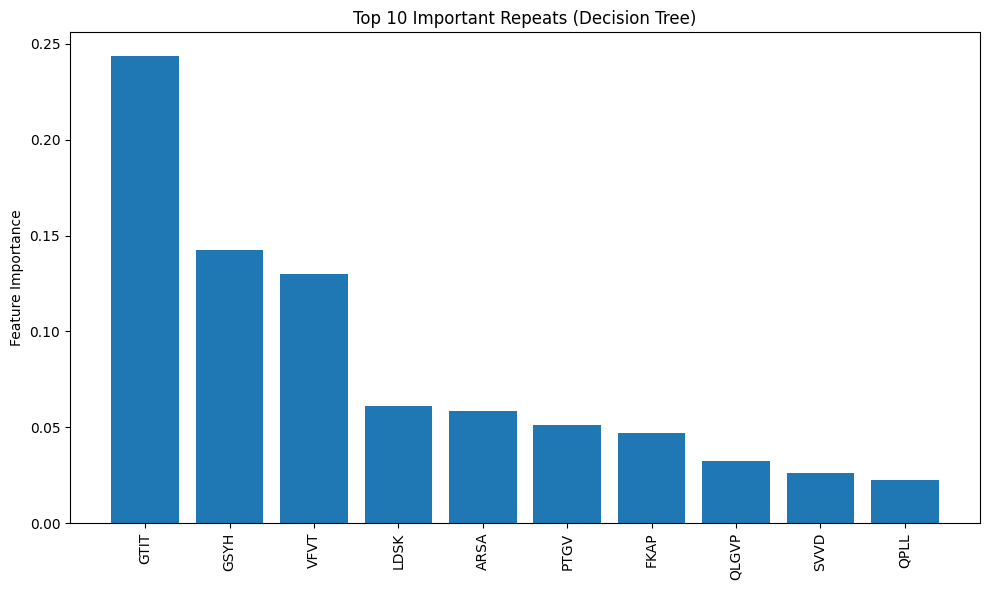

In [12]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2/direct",
    train_folder="../trainSet",
    test_folder="../testSet",
    report_file="classification_report_DTC_direct_2.txt",
    top_features=10
)

Number of unique repeats: 1495
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       0.99      0.99      0.99       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      0.99      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      0.98      0.99       375
  canine-CoV       0.96      0.94      0.95       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       0.78      0.88      0.82         8
  feline-CoV       0.93      0.99      0.96       536
  ferret-CoV       0.73      0.85      0.79        13
hedgehog-CoV       0.86      1.00      0.92         6
 porcine-CoV       1.00    

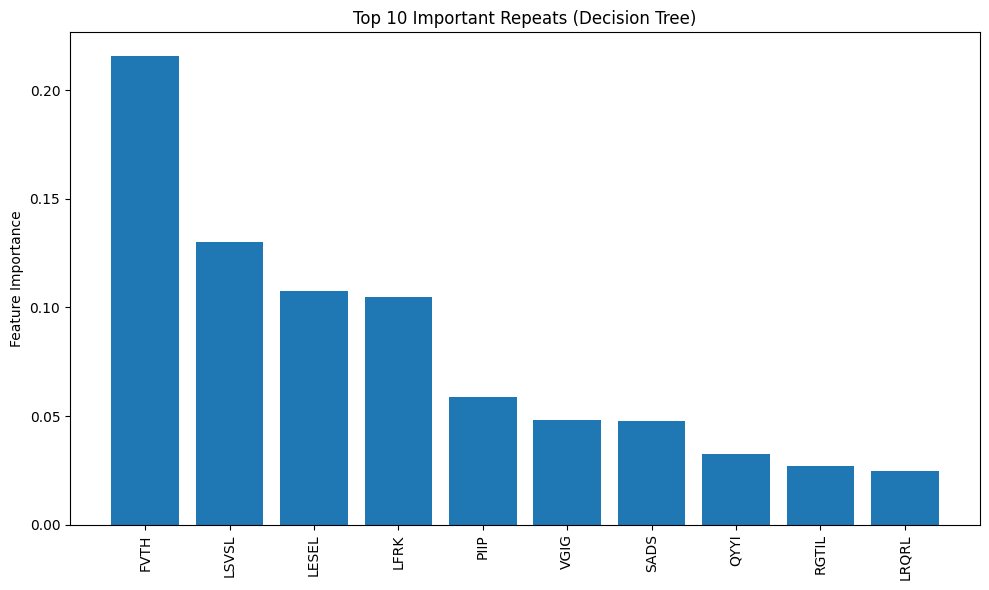

In [13]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2/indirect",
    train_folder="../trainSet",
    test_folder="../testSet",
    report_file="classification_report_DTC_indirect_2.txt",
    top_features=10
)


Number of unique repeats: 982
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.96      0.98        94
   HCoV-HKU1       1.00      0.96      0.98        56
   HCoV-NL63       0.99      1.00      1.00       103
   HCoV-OC43       1.00      0.99      1.00       196
         IBV       1.00      1.00      1.00      2097
    MERS-CoV       1.00      0.99      0.99       138
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       1.00      0.99      0.99       661
     bat-CoV       0.86      1.00      0.92        12
  bovine-CoV       0.99      1.00      1.00       245
  canine-CoV       0.85      0.89      0.87       143
 dolphin-CoV       1.00      1.00      1.00         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.97      0.98      0.98       389
  ferret-CoV       0.82      1.00      0.90         9
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       1.00     

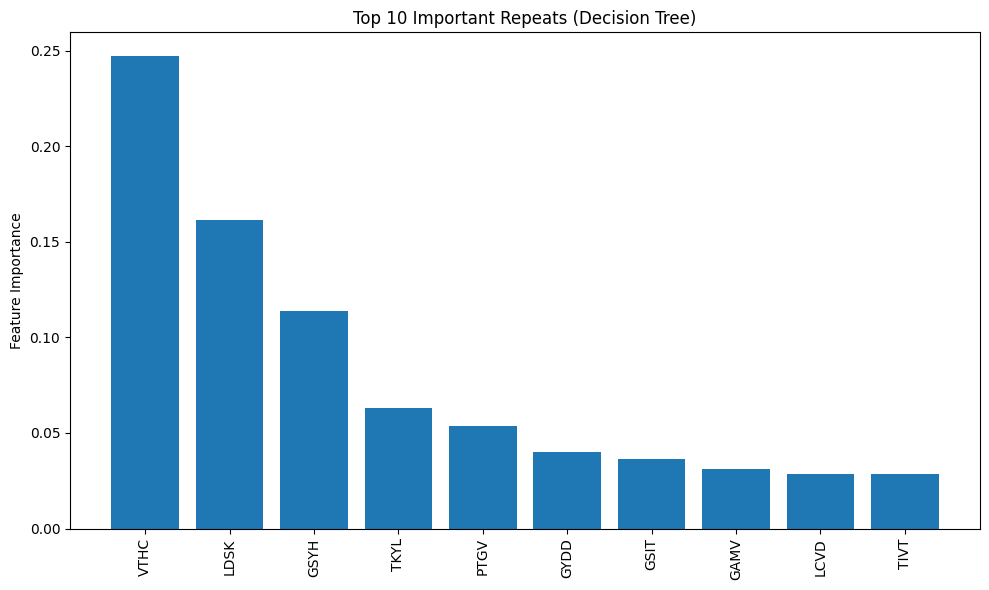

In [14]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2NoDuplicates/direct",
    train_folder="../trainSetNoDuplicates",
    test_folder="../testSetNoDuplicates/",
    report_file="classification_report_DTC_direct_no_duplicates_2.txt",
    top_features=10
)


Number of unique repeats: 1478
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99        94
   HCoV-HKU1       1.00      0.91      0.95        56
   HCoV-NL63       0.98      0.99      0.99       103
   HCoV-OC43       0.98      0.99      0.99       196
         IBV       1.00      1.00      1.00      2097
    MERS-CoV       1.00      0.96      0.98       138
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       1.00      0.99      1.00       661
     bat-CoV       0.92      1.00      0.96        12
  bovine-CoV       0.97      0.98      0.97       245
  canine-CoV       0.95      0.93      0.94       143
 dolphin-CoV       1.00      0.50      0.67         2
  equine-CoV       1.00      0.71      0.83         7
  feline-CoV       0.94      0.99      0.96       389
  ferret-CoV       1.00      0.67      0.80         9
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       0.98    

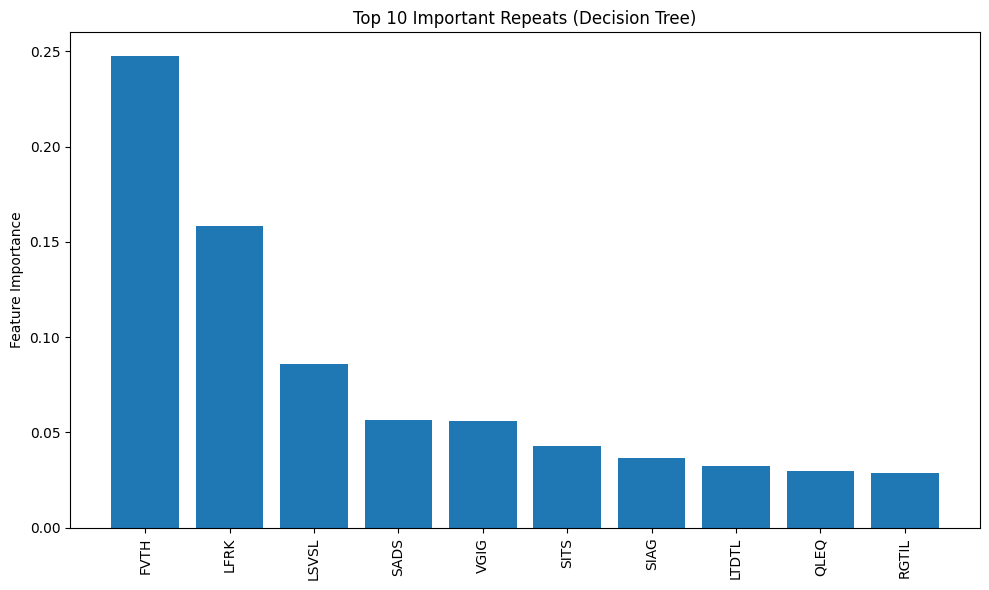

In [15]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2NoDuplicates/indirect",
    train_folder="../trainSetNoDuplicates",
    test_folder="../testSetNoDuplicates/",
    report_file="classification_report_DTC_indirect_no_duplicates_2.txt",
    top_features=10
)


Number of unique repeats: 4509
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.99      1.00       120
   HCoV-HKU1       0.99      0.96      0.97        70
   HCoV-NL63       0.99      0.99      0.99       154
   HCoV-OC43       0.99      0.99      0.99       252
         IBV       0.99      1.00      0.99      2267
    MERS-CoV       0.99      0.98      0.99       198
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       0.97      1.00      0.98       624
     bat-CoV       1.00      0.85      0.92        13
  bovine-CoV       0.99      1.00      0.99       276
  canine-CoV       0.90      0.85      0.88       162
 dolphin-CoV       1.00      0.50      0.67         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.95      0.95      0.95       444
  ferret-CoV       0.89      0.73      0.80        11
hedgehog-CoV       1.00      0.40      0.57         5
 porcine-CoV       0.99    

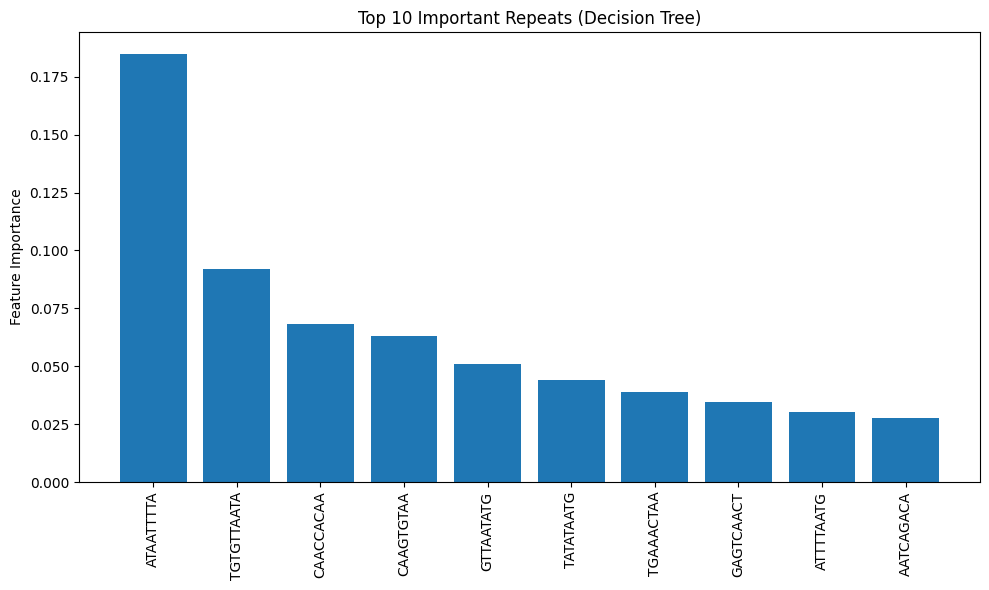

In [2]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2NoDuplicatesNucl/DC",
    train_folder="../trainSetNoDuplicatesNucl",
    test_folder="../testSetNoDuplicatesNucl/",
    report_file="classification_report_DTC_DC_no_duplicates_2.txt",
    top_features=10
)


Number of unique repeats: 6144
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       120
   HCoV-HKU1       0.91      0.99      0.95        70
   HCoV-NL63       1.00      0.99      1.00       154
   HCoV-OC43       0.99      0.99      0.99       252
         IBV       0.99      1.00      0.99      2267
    MERS-CoV       1.00      0.98      0.99       198
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       0.99      1.00      0.99       624
     bat-CoV       1.00      0.62      0.76        13
  bovine-CoV       1.00      0.99      0.99       276
  canine-CoV       0.84      0.90      0.87       162
 dolphin-CoV       1.00      1.00      1.00         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.96      0.94      0.95       444
  ferret-CoV       0.90      0.82      0.86        11
hedgehog-CoV       1.00      0.60      0.75         5
 porcine-CoV       1.00    

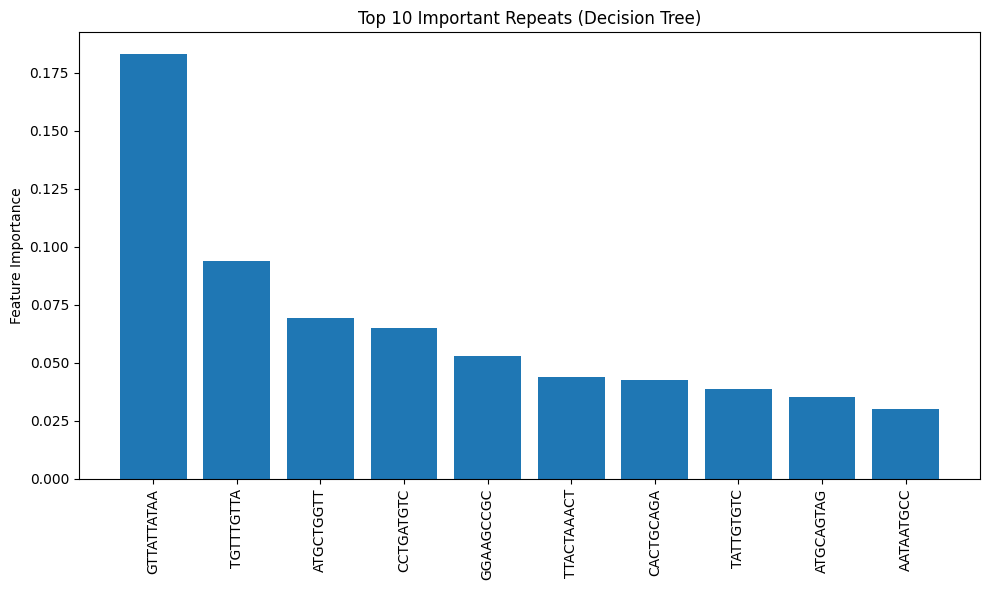

In [3]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2NoDuplicatesNucl/IC",
    train_folder="../trainSetNoDuplicatesNucl",
    test_folder="../testSetNoDuplicatesNucl/",
    report_file="classification_report_DTC_IC_no_duplicates_2.txt",
    top_features=10
)


Number of unique repeats: 6346
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.99      1.00       120
   HCoV-HKU1       0.97      0.94      0.96        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       0.99      0.99      0.99       252
         IBV       0.99      1.00      1.00      2267
    MERS-CoV       1.00      0.97      0.99       198
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       0.97      1.00      0.99       624
     bat-CoV       1.00      1.00      1.00        13
  bovine-CoV       0.99      0.99      0.99       276
  canine-CoV       0.90      0.91      0.90       162
 dolphin-CoV       1.00      0.50      0.67         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.98      0.95      0.97       444
  ferret-CoV       1.00      0.73      0.84        11
hedgehog-CoV       1.00      0.80      0.89         5
 porcine-CoV       1.00    

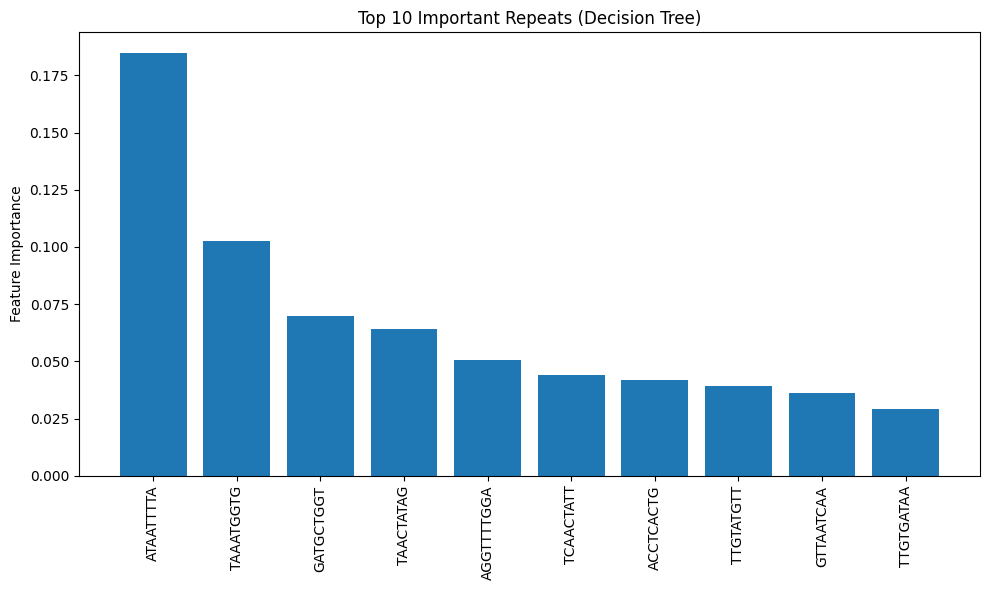

In [4]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2NoDuplicatesNucl/IN",
    train_folder="../trainSetNoDuplicatesNucl",
    test_folder="../testSetNoDuplicatesNucl/",
    report_file="classification_report_DTC_IN_no_duplicates_2.txt",
    top_features=10
)


Number of unique repeats: 8047
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       0.98      0.98      0.98       120
   HCoV-HKU1       0.97      0.96      0.96        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       0.97      0.99      0.98       252
         IBV       1.00      1.00      1.00      2267
    MERS-CoV       0.99      0.97      0.98       198
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       0.97      1.00      0.99       624
     bat-CoV       1.00      1.00      1.00        13
  bovine-CoV       0.99      0.99      0.99       276
  canine-CoV       0.90      0.90      0.90       162
 dolphin-CoV       1.00      0.50      0.67         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.97      0.94      0.96       444
  ferret-CoV       0.91      0.91      0.91        11
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       1.00    

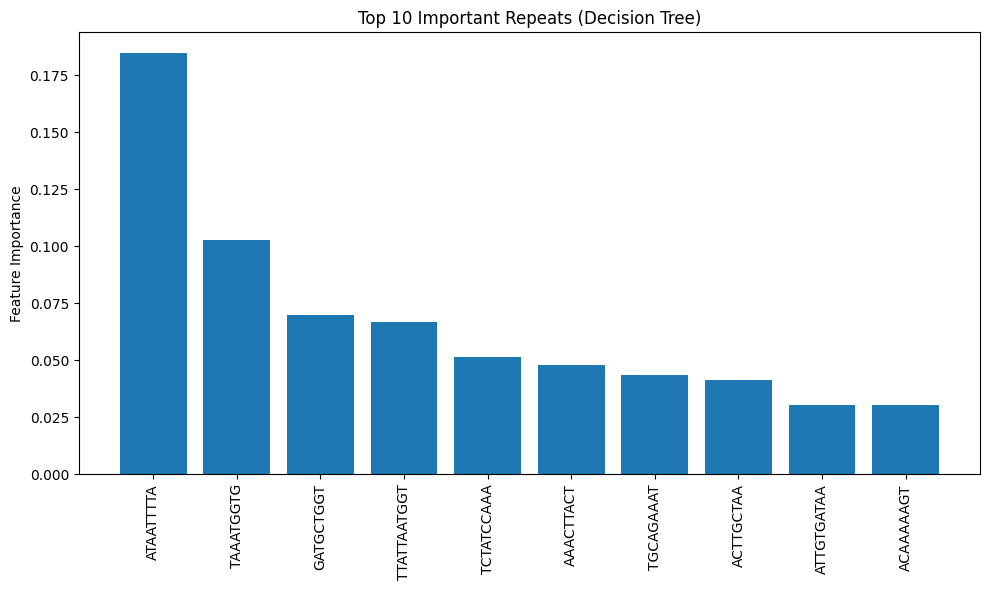

In [5]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2NoDuplicatesNucl/DN",
    train_folder="../trainSetNoDuplicatesNucl",
    test_folder="../testSetNoDuplicatesNucl/",
    report_file="classification_report_DTC_DN_no_duplicates_2.txt",
    top_features=10
)


Number of unique repeats: 6993
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       0.99      0.98      0.99       153
   HCoV-HKU1       0.90      0.98      0.94       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       0.99      0.98      0.98       366
         IBV       0.99      0.99      0.99      3149
    MERS-CoV       1.00      0.97      0.98       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       0.81      0.87      0.84        15
  bovine-CoV       0.99      1.00      0.99       375
  canine-CoV       0.94      0.93      0.93       217
 dolphin-CoV       0.75      1.00      0.86         3
  equine-CoV       1.00      0.50      0.67         8
  feline-CoV       0.95      0.98      0.96       536
  ferret-CoV       0.65      0.85      0.73        13
hedgehog-CoV       0.43      0.50      0.46         6
 porcine-CoV       0.98    

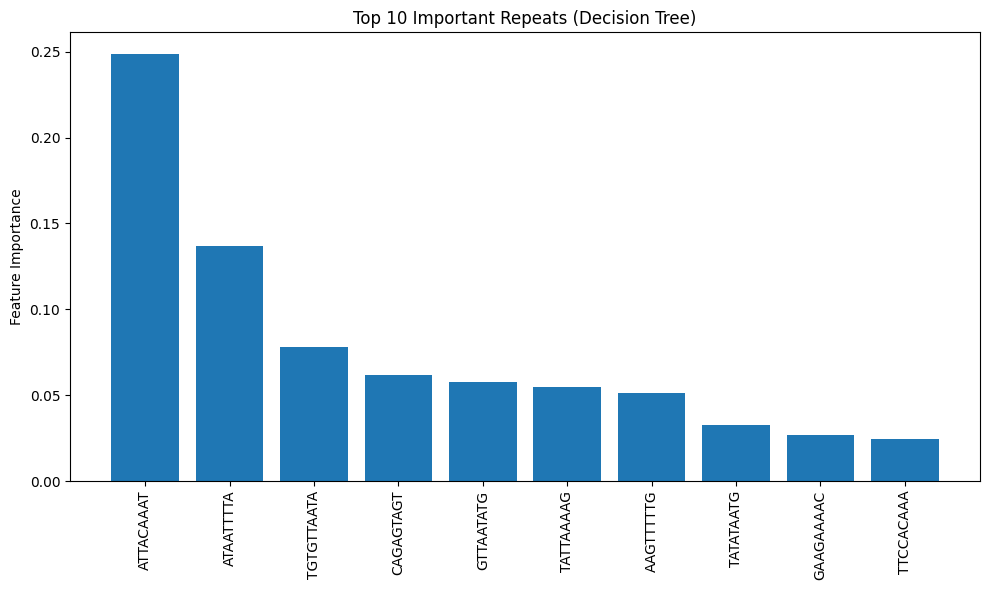

In [6]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba3/DC",
    train_folder="../trainSetNucl",
    test_folder="../testSetNucl/",
    report_file="classification_report_DTC_DC_2.txt",
    top_features=10
)


Number of unique repeats: 9112
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       153
   HCoV-HKU1       0.99      0.98      0.98       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      0.98      0.99       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      0.80      0.89        15
  bovine-CoV       0.99      0.99      0.99       375
  canine-CoV       0.94      0.95      0.94       217
 dolphin-CoV       1.00      0.67      0.80         3
  equine-CoV       1.00      0.75      0.86         8
  feline-CoV       0.95      0.98      0.96       536
  ferret-CoV       1.00      0.92      0.96        13
hedgehog-CoV       0.80      0.67      0.73         6
 porcine-CoV       0.99    

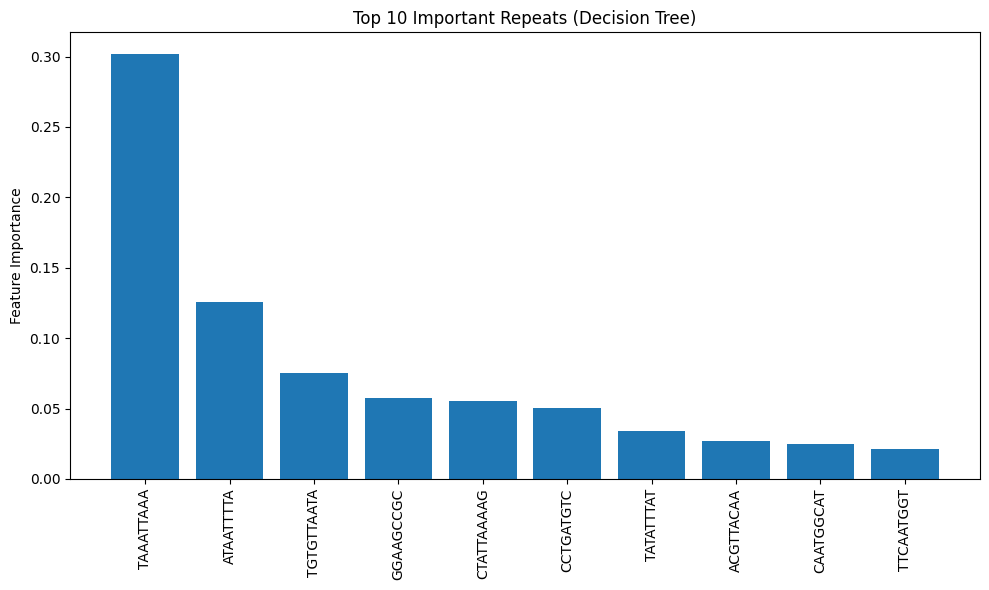

In [7]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba3/IC",
    train_folder="../trainSetNucl",
    test_folder="../testSetNucl/",
    report_file="classification_report_DTC_IC_2.txt",
    top_features=10
)

Number of unique repeats: 9258
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       0.97      0.98      0.98       153
   HCoV-HKU1       0.93      1.00      0.96       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       0.99      0.98      0.99       366
         IBV       0.99      0.99      0.99      3149
    MERS-CoV       0.99      0.96      0.98       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       0.93      0.87      0.90        15
  bovine-CoV       0.99      0.99      0.99       375
  canine-CoV       0.93      0.97      0.95       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.50      0.67         8
  feline-CoV       0.96      0.98      0.97       536
  ferret-CoV       0.92      0.92      0.92        13
hedgehog-CoV       1.00      0.67      0.80         6
 porcine-CoV       0.99    

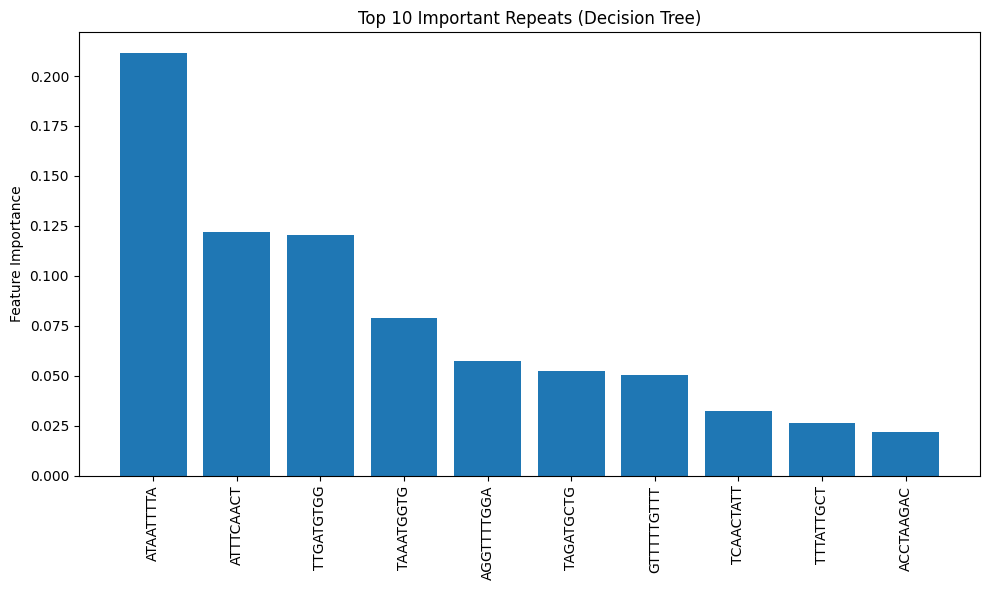

In [2]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba3/IN",
    train_folder="../trainSetNucl",
    test_folder="../testSetNucl/",
    report_file="classification_report_DTC_IN_2.txt",
    top_features=10
)


Number of unique repeats: 11921
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       153
   HCoV-HKU1       0.97      0.98      0.98       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       0.99      0.99      0.99       366
         IBV       0.99      0.99      0.99      3149
    MERS-CoV       0.99      0.97      0.98       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       0.94      1.00      0.97        15
  bovine-CoV       1.00      0.99      1.00       375
  canine-CoV       0.94      0.94      0.94       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.50      0.67         8
  feline-CoV       0.96      0.97      0.96       536
  ferret-CoV       0.71      0.92      0.80        13
hedgehog-CoV       1.00      0.83      0.91         6
 porcine-CoV       0.99   

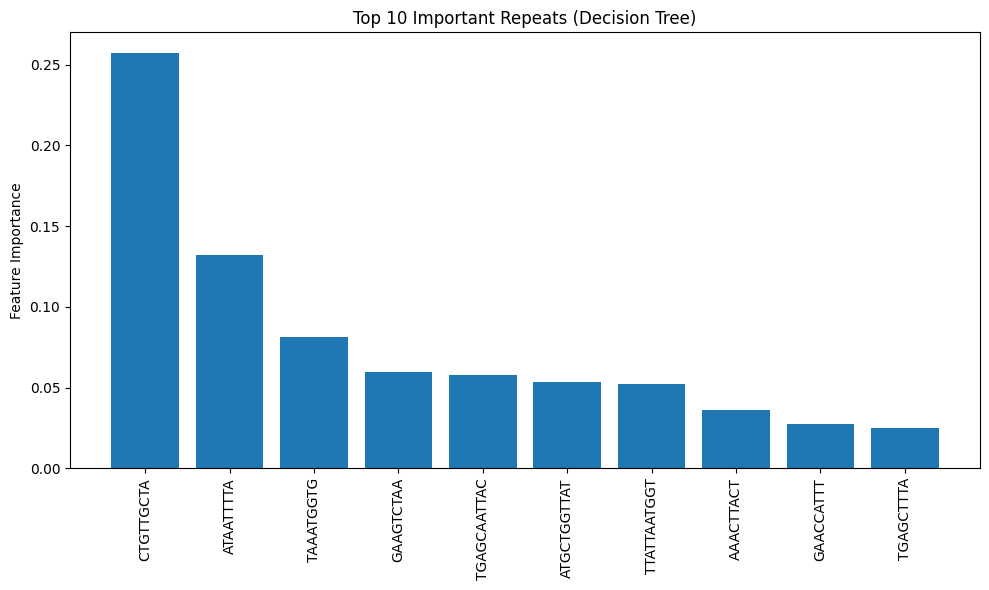

In [3]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba3/DN",
    train_folder="../trainSetNucl",
    test_folder="../testSetNucl/",
    report_file="classification_report_DTC_DN_2.txt",
    top_features=10
)


In [1]:
import os
from Bio import SeqIO
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np


def train_decision_tree(direct_folder, train_folder, test_folder,
                        report_file = None,
                        top_features = 20):
    """
    Train and evaluate a DecisionTreeClassifier on protein sequences using repeat counts as features.
    
    Args:
        direct_folder (str): Folder with repeats (comma-separated format: label,repeat,...).
        train_folder (str): Folder with training FASTA sequences.
        test_folder (str): Folder with testing FASTA sequences.
        report_file (str): Path to save classification report.
        top_features (int): Number of most important features to display/plot.
    
    Returns:
        model: trained DecisionTreeClassifier
        encoder: fitted LabelEncoder
        known_repeats: list of feature names
    """

    # -----------------------------
    # 1️⃣ Load known repeats
    repeats = []
    for file in os.listdir(direct_folder):
        if file.startswith("."):
            continue
        with open(os.path.join(direct_folder, file), "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) >= 2:
                    repeats.append(parts[1])
                    
    known_repeats = list(set(r for r in repeats if "X" not in r))
    known_repeats = list(set(r for r in known_repeats if "N" not in r))
    print(f"Number of unique repeats: {len(known_repeats)}")

    def extract_repeat_counts(sequence, repeat_list):
        return [sequence.count(r) for r in repeat_list]

    # -----------------------------
    # 2️⃣ Stream training set
    X_train, y_train = [], []
    for file in os.listdir(train_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(train_folder, file)
        for record in SeqIO.parse(filepath, "fasta"):
            X_train.append(extract_repeat_counts(str(record.seq), known_repeats))
            y_train.append(file.replace(".fasta", ""))

    # -----------------------------
    # 3️⃣ Stream testing set
    X_test, y_test = [], []
    for file in os.listdir(test_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(test_folder, file)
        for record in SeqIO.parse(filepath, "fasta"):
            X_test.append(extract_repeat_counts(str(record.seq), known_repeats))
            y_test.append(file.replace(".fasta", ""))

    # -----------------------------
    # 4️⃣ Encode labels
    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(y_train)
    y_test_enc = encoder.transform(y_test)

    # -----------------------------
    # 5️⃣ Train model
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train_enc)

    # -----------------------------
    # 6️⃣ Predict
    y_pred_enc = tree.predict(X_test)
    y_pred = encoder.inverse_transform(y_pred_enc)

    y_pred_enc_train = tree.predict(X_train)
    y_pred_train = encoder.inverse_transform(y_pred_enc_train)

    # -----------------------------
    # 7️⃣ Report
    report = classification_report(y_test, y_pred)
    print("Classification report:")
    print(report)
    print("Accuracy score test:", accuracy_score(y_test, y_pred))
    print("Accuracy score train:", accuracy_score(y_train, y_pred_train))

    with open(report_file, "w") as f:
        f.write(report)
        f.write("\nAccuracy score test: " + str(accuracy_score(y_test, y_pred)))
        f.write("\nAccuracy score train: " + str(accuracy_score(y_train, y_pred_train)))

    # -----------------------------
    # 8️⃣ Feature importances
    importances = tree.feature_importances_
    indices = np.argsort(importances)[::-1]

    print(f"\nTop {top_features} most important features (repeats):")
    for i in range(min(top_features, len(indices))):
        repeat = known_repeats[indices[i]]
        importance = importances[indices[i]]
        print(f"{i+1}. {repeat}: {importance:.4f}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_features), importances[indices[:top_features]], align="center")
    plt.xticks(range(top_features), [known_repeats[i] for i in indices[:top_features]], rotation=90)
    plt.title(f"Top {top_features} Important Repeats (Decision Tree)")
    plt.ylabel("Feature Importance")
    plt.tight_layout()
    plt.show()

    return tree, encoder, known_repeats


Number of unique repeats: 1979
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       0.98      0.99      0.98       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       0.99      1.00      1.00       213
   HCoV-OC43       1.00      0.99      1.00       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      1.00      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       0.79      1.00      0.88        15
  bovine-CoV       0.99      1.00      1.00       375
  canine-CoV       0.90      0.96      0.93       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.99      0.98      0.98       536
  ferret-CoV       1.00      1.00      1.00        13
hedgehog-CoV       0.86      1.00      0.92         6
 porcine-CoV       1.00    

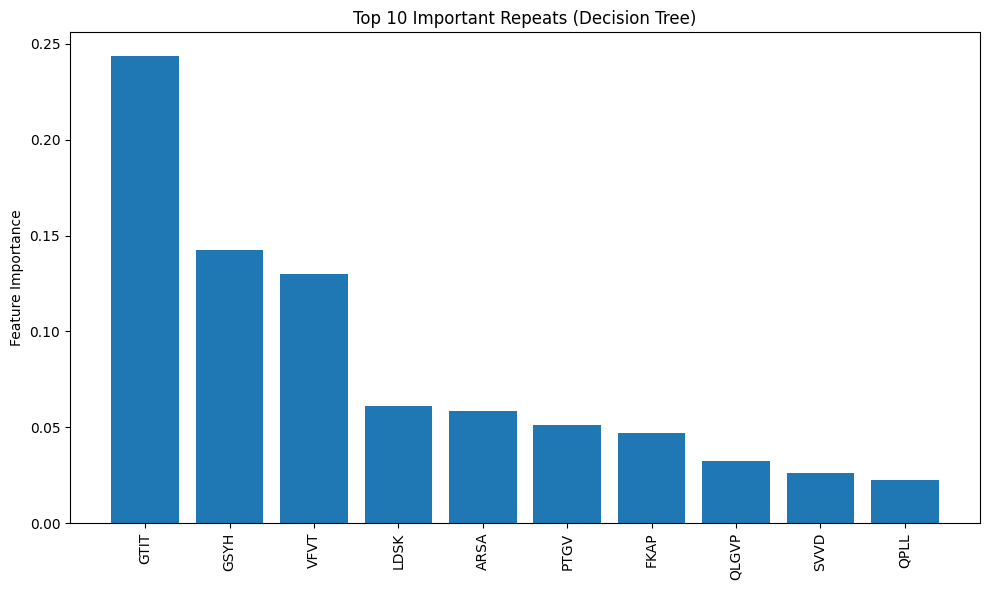

In [2]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2/direct",
    train_folder="../trainSet",
    test_folder="../testSet",
    report_file="proba2Ponovka_DTC_direct.txt",
    top_features=10
)


Number of unique repeats: 2989
Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       153
   HCoV-HKU1       1.00      0.99      0.99       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       0.99      0.99      0.99       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      0.99      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.98      0.98      0.98       375
  canine-CoV       0.95      0.94      0.94       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.93      0.98      0.96       536
  ferret-CoV       1.00      0.85      0.92        13
hedgehog-CoV       0.86      1.00      0.92         6
 porcine-CoV       1.00    

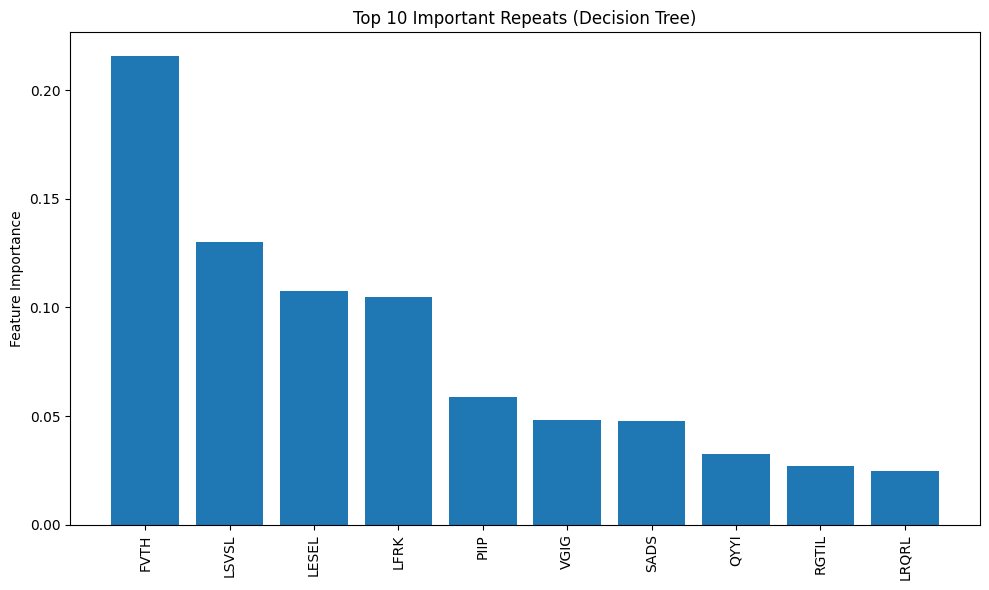

In [3]:
tree, encoder, repeats = train_decision_tree(
    direct_folder="../proba2/indirect",
    train_folder="../trainSet",
    test_folder="../testSet",
    report_file="proba2Ponovka_DTC_indirect.txt",
    top_features=10
)
